In [1]:
import keras
import numpy as np
from keras import layers

In [2]:
from keras.datasets import cifar10
(xtrain, ytrain), (xtest, ytest) =  cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
xtrain.shape

(50000, 32, 32, 3)

In [4]:
class_labels = ['airplane',
                'automobile',
                'bird',
                'cat',
                'deer',
                'dog',
                'frog',
                'horse',
                'ship',
                'truck']

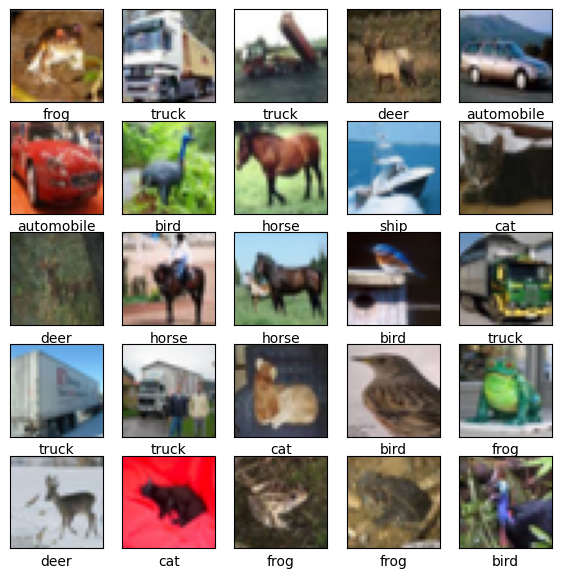

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))

for k in range(25):
  plt.subplot(5, 5, k+1)
  plt.xticks([])
  plt.yticks([])
  plt.xlabel(class_labels[ytrain[k][0]])
  plt.imshow(xtrain[k])


In [6]:
def create_cnn():
  inputs = keras.Input(shape=(32, 32, 3))
  x = layers.Rescaling(1./255)(inputs)

  # block1 : image size down to 16 x 16
  x = layers.Conv2D(32, 3, padding='same', strides=2)(x)
  x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU()(x)

  # block2 : image size down to 8 x 8
  x = layers.Conv2D(64, 3, padding='same', strides=2)(x)
  x = layers.BatchNormalization()(x)
  x = layers.LeakyReLU()(x)

  x = layers.Flatten()(x)
  x = layers.Dense(64)(x)
  x = layers.LeakyReLU()(x)
  x = layers.Dropout(0.2)(x)

  # output layer
  outputs = layers.Dense(10, activation='softmax')(x)

  return keras.Model(inputs=inputs, outputs=outputs)

In [7]:
model = create_cnn()
opt = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.fit(xtrain, ytrain, epochs=10, shuffle=True, batch_size=32)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.4002 - loss: 1.6930
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.5035 - loss: 1.3950
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 25ms/step - accuracy: 0.5558 - loss: 1.2594
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.5864 - loss: 1.1720
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 24ms/step - accuracy: 0.6099 - loss: 1.1062
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6264 - loss: 1.0555
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6470 - loss: 1.0047
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 25ms/step - accuracy: 0.6610 - loss: 0.9594
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6767 - loss: 0.9191
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.6876 - loss: 0.8880


In [8]:
z = model.predict(xtest)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


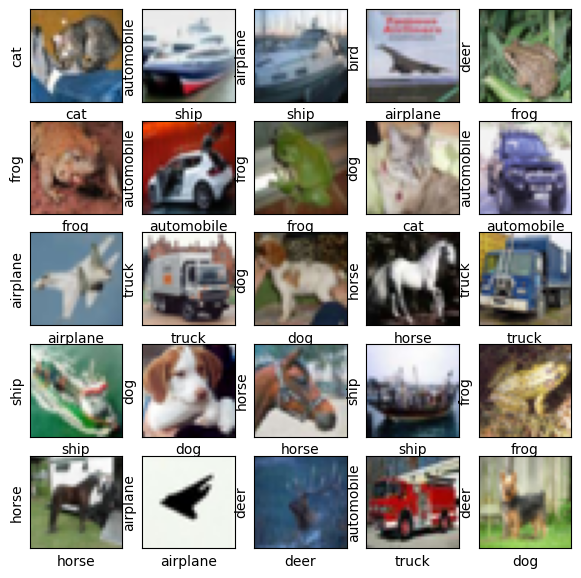

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 7))

for k in range(25):
  plt.subplot(5, 5, k+1)
  plt.xticks([])
  plt.yticks([])
  label = ytest[k][0]
  plt.xlabel(class_labels[label])
  label = np.argmax(z[k])
  plt.ylabel(class_labels[label])
  plt.imshow(xtest[k])